# Step 1: Mount/connect google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2: Dataset preparation

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
file_path = '/content/drive/MyDrive/AI_Classroom/housing.csv'
data = pd.read_csv(file_path)

In [ ]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
data.tail(6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20634,-121.56,39.27,28.0,2332.0,395.0,1041.0,344.0,3.7125,116800.0,INLAND
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [ ]:
data.shape   # attribute (no brackets)

(20640, 10)

In [ ]:
data.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [ ]:
rows, cols = data.shape

In [ ]:
rows

20640

In [ ]:
cols

10

# Info() vs describe()

info():

- gives information about the structure of dataframe (data): non-nulll counts, memory usage, *column* names with their datatypes
- to find missing value, understand column types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


describe():
- understand distribution of values: outliers, skewed
- descriptive statistic of **numeric column**: mean, std.....

In [ ]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Missing data

In [ ]:
missing_data = data.isna().sum()
print(missing_data)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
207/20624

0.010036850271528317

In [ ]:
missing_data_ratio = missing_data/rows
missing_data_ratio

,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,0.010029
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


# One-hot encoding and correlation:

- Use pandas.get_dummies()
- use dataframe.corr()

In [ ]:
# one hot encoding
data_encoded = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True) # drop to avoid multiple colininearity

correlation_matrix = data_encoded.corr()  # correlation nikalyo
print(correlation_matrix)

                            longitude  latitude  housing_median_age  \
longitude                    1.000000 -0.924664           -0.108197   
latitude                    -0.924664  1.000000            0.011173   
housing_median_age          -0.108197  0.011173            1.000000   
total_rooms                  0.044568 -0.036100           -0.361262   
total_bedrooms               0.069608 -0.066983           -0.320451   
population                   0.099773 -0.108785           -0.296244   
households                   0.055310 -0.071035           -0.302916   
median_income               -0.015176 -0.079809           -0.119034   
median_house_value          -0.045967 -0.144160            0.105623   
ocean_proximity_INLAND      -0.055575  0.351166           -0.236645   
ocean_proximity_ISLAND       0.009446 -0.016572            0.017020   
ocean_proximity_NEAR BAY    -0.474489  0.358771            0.255172   
ocean_proximity_NEAR OCEAN   0.045509 -0.160818            0.021622   

     

# Drop missing values

1. Dropping rows:

dataframe.dropna()

In [ ]:
data_drop_missing_rows = data.dropna()   # drop the rows with null(missing) values
print(data_drop_missing_rows.shape)

(20433, 10)


In [ ]:
data_drop_missing_rows.isna().sum()   # ajhai pani kei null value cha ki nai check

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


2. Dropping column:

dataframe.drop(columns = _____)

In [ ]:
data_drop_missing_columns = data_drop_missing_rows.drop(columns=['total_bedrooms'])
print(data_drop_missing_columns.shape)

(20433, 9)


# Looking up specific data

In [ ]:
# condition = data['housing_median_age'] < 25
# temporary_dataframe = data.loc[condition]

In [ ]:
temporary_dataframe = data.loc[data['population']>500]
temporary_dataframe.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY


* Assignment: Look up latitude == 37.85

In [ ]:
temp = data.loc[data['latitude']==37.85]
temp.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
10,-122.26,37.85,52.0,2202.0,434.0,910.0,402.0,3.2031,281500.0,NEAR BAY


## Assignment:
 Above, we removed the missing values, for the assignment I want you to fill the missing values with median values.

 Hints: calculate median, then use 'dataframe['column'].fillna(median)

# Create new columns

concat(side by side) : by creating another dataframe or series(hijo done)

= pandas.concat(dataframe1, dataframe2, axis = 1)  axis is 1 because we wish to concatenate to the side(new column to be added)

In [ ]:
ocean_proximity_encoded = pd.get_dummies(data['ocean_proximity'], drop_first=True)  # dataframe 2

data = pd.concat([data, ocean_proximity_encoded], axis = 1)

print(data)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  media

In [ ]:
data.shape

(20640, 18)

# Matplotlib to visualize:

- type = plt.scatter(), dataframe.plot(kind= 'hist')  # k plot garne
- title = plt.title('___')
- label = plt.xlabel('___') and plt.ylabel()
- legend = plt.legend(['___'])
- plt.show()   # to show


In [ ]:
import matplotlib.pyplot as plt

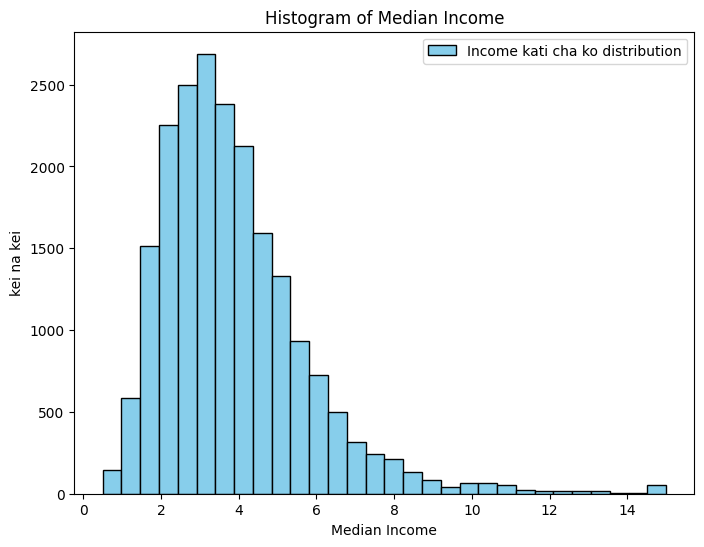

In [ ]:
data['median_income'].plot(kind='hist', bins=30, color = 'skyblue', edgecolor = 'black', figsize=(8,6))
plt.title('Histogram of Median Income')
plt.xlabel('Median Income')
plt.ylabel('kei na kei')
plt.legend(['Income kati cha ko distribution'])
plt.show()

In [ ]:
data.shape

(20640, 18)

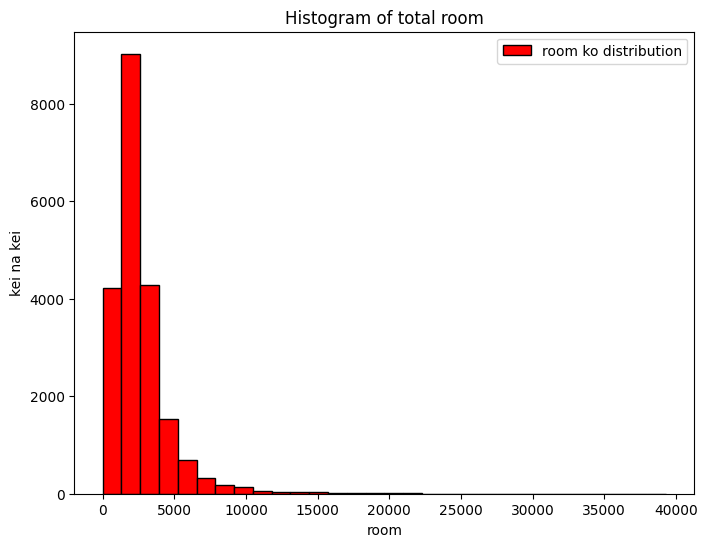

In [ ]:
data['total_rooms'].plot(kind='hist', bins=30, color = 'red', edgecolor = 'black', figsize=(8,6))  # k plot garne
plt.title('Histogram of total room')
plt.xlabel('room')
plt.ylabel('kei na kei')
plt.legend(['room ko distribution'])
plt.show()

# Save the modified (wrangled) data

In [ ]:
file_path

'/content/drive/MyDrive/AI_Classroom/housing.csv'

In [ ]:
data.to_csv('/content/drive/MyDrive/AI_Classroom/modified_housing.csv', index = False)

# Next steps:
model building, model training, model evaluation, .....